# 03 — Gate 2: one-detector probe (e5 + XGBoost), direct -> indirect
**v2: realistic indirect target.** Indirect attacks are now a benign BIPIA document (email/table) with a text-attack instruction injected, plus clean documents as benigns -- a true instruction-in-document distribution, not bare attack strings.

Train on **direct** (deepset), freeze the operating threshold on the source, apply unchanged to the **indirect** distribution, and read S/FNCR/ECE_atk.

**Question:** does miss-severity S stay catastrophic on REAL indirect samples while AUROC roughly holds? **GPU recommended.**

## Session bootstrap

In [10]:
# === SESSION BOOTSTRAP (run first, every session) ===
from google.colab import drive
drive.mount('/content/drive')
import os, sys
DRIVE_ROOT = '/content/drive/MyDrive/PICALIB_Research'
REPO_DIR   = os.path.join(DRIVE_ROOT, 'picalib-research')
!git config --global user.name  "Md Anas Biswas"
!git config --global user.email "anasbiswas@gmail.com"
!git config --global credential.helper "store --file={DRIVE_ROOT}/.git-credentials"
%cd {REPO_DIR}
sys.path.insert(0, 'src')
!git pull
print('Session ready - identity set, src/ on path, repo pulled.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/PICALIB_Research/picalib-research
Already up to date.
Session ready - identity set, src/ on path, repo pulled.


## Dependencies + device

In [11]:
!pip install -q sentence-transformers xgboost scikit-learn datasets
import torch
print('CUDA:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

CUDA: True | Tesla T4


## Load source (deepset direct) + realistic indirect target (BIPIA)
First run computes + caches embeddings; re-runs reload. Note the new cache file `emb_bipia_indirect.npy` (distinct from the old bare-string cache).

In [12]:
import importlib, data_loaders, detectors, metrics
for m in (data_loaders, detectors, metrics): importlib.reload(m)
from data_loaders import load_deepset, load_bipia_indirect
from detectors import embed_e5, train_xgb, predict_p, threshold_at_fpr, auroc
from metrics import all_metrics, severity_S, bootstrap_ci
import numpy as np, pandas as pd, os
from sklearn.model_selection import train_test_split

deepset = load_deepset()                     # direct + benign (SOURCE)
bipia   = load_bipia_indirect(n_attack=400)  # realistic indirect (TARGET)
print('deepset', len(deepset),
      '| bipia indirect', len(bipia),
      '(attack', int((bipia.label==1).sum()), '/ benign', int((bipia.label==0).sum()), ')')

os.makedirs('data', exist_ok=True)
def cached_embed(texts, path):
    if os.path.exists(path):
        print('load cached', path); return np.load(path)
    emb = embed_e5(list(texts)); np.save(path, emb); return emb
E_deepset = cached_embed(deepset.text, 'data/emb_deepset.npy')
E_bipia   = cached_embed(bipia.text,   'data/emb_bipia_indirect.npy')
print('emb', E_deepset.shape, E_bipia.shape)

BIPIA indirect: 1097 contexts, 150 text attacks
deepset 662 | bipia indirect 1177 (attack 399 / benign 778 )
load cached data/emb_deepset.npy


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

emb (662, 768) (1177, 768)


## Train on direct, freeze threshold at 1% FPR on source
Source-threshold transfer (cite Gate AI 2606.02959). *Probe caveat: threshold in-sample on train benigns; final uses out-of-fold.*

In [13]:
idx = np.arange(len(deepset))
tr, te = train_test_split(idx, test_size=0.3, stratify=deepset.label, random_state=0)
Xtr, ytr = E_deepset[tr], deepset.label.values[tr]
Xte, yte = E_deepset[te], deepset.label.values[te]
clf = train_xgb(Xtr, ytr, seed=0)
p_tr = predict_p(clf, Xtr)
t = threshold_at_fpr(p_tr[ytr==0], target_fpr=0.01)
print(f'frozen source threshold t = {t:.4f}')

frozen source threshold t = 0.0210


## Source (direct) vs target (realistic indirect) at the FROZEN threshold

In [14]:
p_s = predict_p(clf, Xte)
m_s = all_metrics(yte, p_s, t=t); m_s['AUROC'] = auroc(yte, p_s)

y_tgt = bipia.label.values            # BIPIA's OWN attacks + benigns (fully indirect)
p_t = predict_p(clf, E_bipia)
m_t = all_metrics(y_tgt, p_t, t=t); m_t['AUROC'] = auroc(y_tgt, p_t)

rows = ['AUROC','FNR','S','FNCR','HCFN','ECE_atk','ECE_pooled']
cmp = pd.DataFrame({'source(direct)':[m_s[k] for k in rows],
                    'target(indirect)':[m_t[k] for k in rows]}, index=rows).round(4)
print(f'frozen t = {t:.4f}  | source n_attack={m_s["n_attacks"]} (misses {m_s["n_misses"]}),'
      f' target n_attack={m_t["n_attacks"]} (misses {m_t["n_misses"]})\n')
print(cmp.to_string())

frozen t = 0.0210  | source n_attack=79 (misses 2), target n_attack=399 (misses 0)

            source(direct)  target(indirect)
AUROC               0.9669            0.6191
FNR                 0.0253            0.0000
S                      NaN            0.0000
FNCR                0.0248            0.0000
HCFN                0.0253            0.0000
ECE_atk             0.1268            0.0264
ECE_pooled          0.0390            0.6242


## Bootstrap 95% CIs on S

In [15]:
s_pt, s_lo, s_hi = bootstrap_ci(severity_S, yte, p_s, n_boot=1000, t=t)
t_pt, t_lo, t_hi = bootstrap_ci(severity_S, y_tgt, p_t, n_boot=1000, t=t)
print(f'S source {s_pt} [{s_lo:.3f}, {s_hi:.3f}]  (NaN = too few misses to estimate)')
print(f'S target {t_pt:.3f} [{t_lo:.3f}, {t_hi:.3f}]')

S source nan [0.000, 0.000]  (NaN = too few misses to estimate)
S target 0.000 [0.000, 0.000]


## Figure + save report

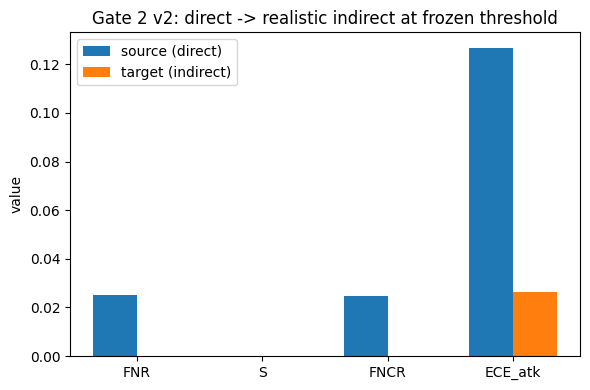

saved figure + reports/gate2_source_vs_target.csv


In [16]:
import matplotlib.pyplot as plt
keys = ['FNR','S','FNCR','ECE_atk']
xs = np.arange(len(keys)); w = 0.35
fig, ax = plt.subplots(figsize=(6,4))
sv = [0 if (isinstance(m_s[k],float) and m_s[k]!=m_s[k]) else m_s[k] for k in keys]
ax.bar(xs-w/2, sv, w, label='source (direct)')
ax.bar(xs+w/2, [m_t[k] for k in keys], w, label='target (indirect)')
ax.set_xticks(xs); ax.set_xticklabels(keys); ax.set_ylabel('value')
ax.set_title('Gate 2 v2: direct -> realistic indirect at frozen threshold'); ax.legend()
plt.tight_layout(); os.makedirs('figures', exist_ok=True)
plt.savefig('figures/gate2_source_vs_target.png', dpi=150); plt.show()
os.makedirs('reports', exist_ok=True)
cmp.to_csv('reports/gate2_source_vs_target.csv')
print('saved figure + reports/gate2_source_vs_target.csv')

## Verdict

In [17]:
dA = m_s['AUROC'] - m_t['AUROC']
Stgt = m_t['S']
print('INTERPRETATION')
print(f"  AUROC : {m_s['AUROC']:.3f} -> {m_t['AUROC']:.3f}  (drop {dA:.3f})")
print(f"  S     : {m_s['S']} -> {Stgt}")
print(f"  FNR   : {m_s['FNR']:.3f} -> {m_t['FNR']:.3f}")
print(f"  FNCR  : {m_s['FNCR']:.3f} -> {m_t['FNCR']:.3f}")
if (not np.isnan(Stgt)) and Stgt > 0.5 and m_t['FNCR'] > m_s['FNCR']:
    print('\n  -> CORE EFFECT HOLDS on realistic indirect samples:')
    print('     missed indirect attacks are waved through with high confidence (S high).')
    if dA < 0.15:
        print('     AUROC roughly holds -> calibration/operating-point failure. SCALE UP.')
    else:
        print('     AUROC also drops -> mixed discrimination+calibration failure (still real).')
else:
    print('\n  -> Severity did NOT hold on realistic indirect. The earlier S=0.99 was')
    print('     likely an artefact of bare attack strings. Reassess before the full panel.')

INTERPRETATION
  AUROC : 0.967 -> 0.619  (drop 0.348)
  S     : nan -> 0.0
  FNR   : 0.025 -> 0.000
  FNCR  : 0.025 -> 0.000

  -> Severity did NOT hold on realistic indirect. The earlier S=0.99 was
     likely an artefact of bare attack strings. Reassess before the full panel.


---
## Commit + push

In [18]:
!git add -A
!git commit -m "Gate 2 v2: realistic indirect (BIPIA context-assembled) direct->indirect transfer"
!git push
print('Pushed. Confirm GitHub + Drive in sync.')

[main 09d9b4a] Gate 2 v2: realistic indirect (BIPIA context-assembled) direct->indirect transfer
 4 files changed, 90 insertions(+), 9 deletions(-)
 rewrite figures/gate2_source_vs_target.png (99%)
 rewrite notebooks/03_gate2_detector_probe.ipynb (95%)
Enumerating objects: 19, done.
Counting objects: 100% (19/19), done.
Delta compression using up to 8 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 31.98 KiB | 1.88 MiB/s, done.
Total 10 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/anasbiswas1/picalib-research.git
   cba4199..09d9b4a  main -> main
Pushed. Confirm GitHub + Drive in sync.


SCORE DISTRIBUTIONS  (p = P(attack))
  source benign   n= 120  mean=0.093  med=0.015  p10=0.001  p90=0.254
  indirect benign n= 778  mean=0.957  med=0.985  p10=0.888  p90=0.998
  indirect attack n= 399  mean=0.974  med=0.992  p10=0.939  p90=0.999

At the frozen source threshold t = 0.0210:
  source   benign FPR : 45.0%   (designed ~1%)
  indirect benign FPR : 100.0%   <- the tell
  indirect attack TPR : 100.0%

indirect-only AUROC (attack vs benign docs): 0.619
corr(score, text length): -0.014   (high => length shortcut)


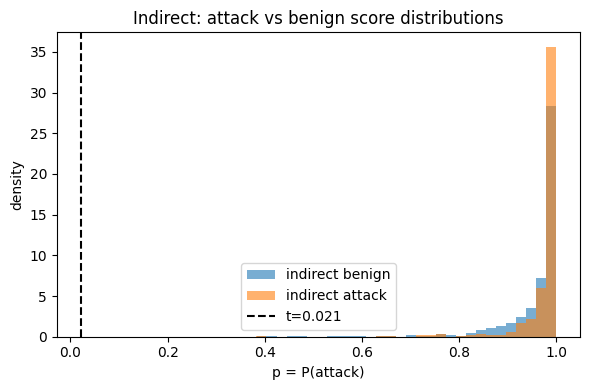

In [19]:
import numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import roc_auc_score

p_t = predict_p(clf, E_bipia); y = bipia.label.values
pa, pb = p_t[y==1], p_t[y==0]          # indirect attack / benign scores
pbs = p_s[yte==0]                       # source benign scores

def s(x): return f"mean={x.mean():.3f}  med={np.median(x):.3f}  p10={np.percentile(x,10):.3f}  p90={np.percentile(x,90):.3f}"
print("SCORE DISTRIBUTIONS  (p = P(attack))")
print(f"  source benign   n={len(pbs):4d}  {s(pbs)}")
print(f"  indirect benign n={len(pb):4d}  {s(pb)}")
print(f"  indirect attack n={len(pa):4d}  {s(pa)}")

print(f"\nAt the frozen source threshold t = {t:.4f}:")
print(f"  source   benign FPR : {(pbs>=t).mean():.1%}   (designed ~1%)")
print(f"  indirect benign FPR : {(pb>=t).mean():.1%}   <- the tell")
print(f"  indirect attack TPR : {(pa>=t).mean():.1%}")
print(f"\nindirect-only AUROC (attack vs benign docs): {roc_auc_score(y,p_t):.3f}")
print(f"corr(score, text length): {np.corrcoef(p_t, bipia.text.str.len().values)[0,1]:.3f}   (high => length shortcut)")

plt.figure(figsize=(6,4))
plt.hist(pb, bins=30, alpha=.6, density=True, label='indirect benign')
plt.hist(pa, bins=30, alpha=.6, density=True, label='indirect attack')
plt.axvline(t, color='k', ls='--', label=f't={t:.3f}')
plt.xlabel('p = P(attack)'); plt.ylabel('density'); plt.legend()
plt.title('Indirect: attack vs benign score distributions'); plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/gate2_indirect_scores.png', dpi=150); plt.show()

In [20]:
%cd {REPO_DIR}
import os
print("src/:", sorted(f for f in os.listdir('src') if f.endswith('.py')))
print("notebooks/:", sorted(f for f in os.listdir('notebooks') if f.endswith('.ipynb')))

/content/drive/MyDrive/PICALIB_Research/picalib-research
src/: ['data_loaders.py', 'dedup.py', 'detectors.py', 'metrics.py', 'reslog.py']
notebooks/: ['00_setup.ipynb', '01_metric_harness.ipynb', '02_gate1_data_dedup.ipynb', '03_gate2_detector_probe.ipynb', '04_gate2_released_detectors.ipynb']
